# Task 5 — Addestramento di più classificatori con Scikit-Learn

> 📄 Documentazione completa e motivazioni: [`docs/task5.md`](../docs/task5.md)

## 1. Import e configurazione

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, f1_score,
                             average_precision_score, roc_auc_score,
                             precision_recall_curve, PrecisionRecallDisplay)

SEED = 10
np.random.seed(SEED)
pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")
print("Librerie importate. SEED =", SEED)

Librerie importate. SEED = 10


## 2. Caricamento di `training.csv`

In [ ]:
df = pd.read_csv("../data/processed/training.csv", sep=",")
print("Dimensioni:", df.shape)
print("\nDistribuzione del target (y):")
print(df["y"].value_counts())
print("\nProporzione classe 'yes':",
      round(df["y"].mean() * 100, 2), "%")
df.head()

## 3. Rimozione della *data leakage*: la feature `duration`
### Perché `duration` è un problema
### Il legame diretto con `real_settings.csv`

In [ ]:
# Rimuoviamo 'duration' per evitare data leakage (coerente con real_settings.csv)
df_model = df.drop(columns=["duration"])

# Separiamo feature (X) e target (y)
X = df_model.drop(columns=["y"])
y = df_model["y"]

print("Feature rimaste:", X.shape[1])
print("Colonne:", list(X.columns))

Feature rimaste: 18
Colonne: ['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'campaign', 'pdays', 'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx', 'euribor3m', 'nr.employed']


## 4. Distinzione tra attributi numerici e categorici

In [ ]:
# Selezione automatica per tipo, senza cicli (Lezione 3: numerici vs nominali)
num_cols = X.select_dtypes(include=["int64", "float64"]).columns
cat_cols = X.select_dtypes(include="object").columns

print(f"Attributi NUMERICI ({len(num_cols)}):")
print(" ", list(num_cols))
print(f"\nAttributi CATEGORICI ({len(cat_cols)}):")
print(" ", list(cat_cols))

Attributi NUMERICI (8):
  ['age', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'euribor3m', 'nr.employed']

Attributi CATEGORICI (10):
  ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']


/tmp/ipykernel_707/611006401.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include="object").columns


## 5. Separazione in training set e test set (holdout 70/30 stratificato)

In [ ]:
# Holdout stratificato 70/30 (Lezione 8)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    stratify=y,          # conserva la proporzione delle classi
    random_state=SEED    # riproducibilità
)

print(f"Training set: {X_train.shape[0]} campioni")
print(f"Test set:     {X_test.shape[0]} campioni")
print(f"\nProporzione 'yes' nel training: {y_train.mean():.4f}")
print(f"Proporzione 'yes' nel test:     {y_test.mean():.4f}")
print("\n-> le proporzioni coincidono: la stratificazione ha funzionato.")

Training set: 28823 campioni
Test set:     12353 campioni

Proporzione 'yes' nel training: 0.1445
Proporzione 'yes' nel test:     0.1445

-> le proporzioni coincidono: la stratificazione ha funzionato.


## 6. Costruzione del preprocessing con `ColumnTransformer`
### Perché la pipeline e non trasformare i dati "a mano"?
### I due rami

In [ ]:
# Ramo numerico: imputazione mediana + standardizzazione (Lezione 11)
num_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

# Ramo categorico: imputazione moda + one-hot encoding (Lezione 11)
cat_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

# ColumnTransformer: applica ogni ramo al gruppo di colonne corretto
preprocessor = ColumnTransformer([
    ("num", num_pipe, num_cols),
    ("cat", cat_pipe, cat_cols),
])

print("Preprocessor costruito:")
print(preprocessor)

Preprocessor costruito:


ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 Index(['age', 'campaign', 'pdays', 'previous', 'emp.var.rate',
       'cons.price.idx', 'euribor3m', 'nr.employed'],
      dtype='str')),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'd

## 7. Gestione dello sbilanciamento delle classi
### Conseguenza 1 — l'accuracy è fuorviante
### Conseguenza 2 — serve ribilanciare il costo degli errori

## 8. Definizione dei cinque classificatori e delle griglie di iperparametri

In [ ]:
# Dizionario {nome: (stimatore, griglia di iperparametri)}
# I modelli che lo supportano usano class_weight='balanced' (Sezione 7).
models = {
    "Naive Bayes": (
        GaussianNB(),
        {"clf__var_smoothing": [1e-9, 1e-7, 1e-5]},
    ),
    "KNN": (
        KNeighborsClassifier(),
        {"clf__n_neighbors": [15, 31, 51],
         "clf__weights": ["uniform", "distance"]},
    ),
    "Albero": (
        DecisionTreeClassifier(class_weight="balanced", random_state=SEED),
        {"clf__max_depth": [5, 10, None],
         "clf__min_samples_leaf": [1, 20]},
    ),
    "Logistica": (
        LogisticRegression(class_weight="balanced", max_iter=1000, random_state=SEED),
        {"clf__C": [0.1, 1.0, 10.0]},
    ),
    "Random Forest": (
        RandomForestClassifier(class_weight="balanced", random_state=SEED, n_jobs=-1),
        {"clf__n_estimators": [200],
         "clf__max_depth": [10, None],
         "clf__min_samples_leaf": [1, 5]},
    ),
}

print("Modelli definiti:", list(models.keys()))

Modelli definiti: ['Naive Bayes', 'KNN', 'Albero', 'Logistica', 'Random Forest']


## 9. Scelta della metrica di ottimizzazione

## 10. Addestramento, tuning e valutazione dei cinque modelli

In [ ]:
# Cross-validation stratificata per il tuning (Lezione 8-9)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

def valuta_modello(nome):
    # Costruisce la pipeline, ottimizza gli iperparametri via GridSearchCV
    # e valuta il modello migliore sul test set. Restituisce una Series di risultati.
    stimatore, griglia = models[nome]

    # Pipeline completa: preprocessing + classificatore
    pipe = Pipeline([("prep", preprocessor), ("clf", stimatore)])

    # Tuning con cross-validation, ottimizzando la F1 (Sezione 9)
    search = GridSearchCV(pipe, griglia, scoring="f1", cv=cv, n_jobs=-1)
    search.fit(X_train, y_train)

    best = search.best_estimator_
    pred = best.predict(X_test)
    # Probabilità per le metriche di ranking (tutti questi modelli hanno predict_proba)
    proba = best.predict_proba(X_test)[:, 1]

    return pd.Series({
        "modello": nome,
        "best_params": str(search.best_params_),
        "cv_f1": search.best_score_,
        "test_f1": f1_score(y_test, pred),
        "test_pr_auc": average_precision_score(y_test, proba),
        "test_roc_auc": roc_auc_score(y_test, proba),
        "test_accuracy": (pred == y_test).mean(),
        "_estimator": best,
        "_pred": pred,
        "_proba": proba,
    })

# Applichiamo la funzione a tutti i modelli senza cicli espliciti.
# apply che restituisce una Series produce direttamente un DataFrame.
risultati = (pd.Index(list(models.keys()))
             .to_series()
             .apply(valuta_modello)
             .reset_index(drop=True))

print("Addestramento e tuning completati per tutti i modelli.")

Addestramento e tuning completati per tutti i modelli.


### Tabella comparativa dei risultati

In [ ]:
# Colonne metriche (escludiamo quelle che iniziano con '_', di servizio)
colonne_metriche = ["modello", "cv_f1", "test_f1",
                    "test_pr_auc", "test_roc_auc", "test_accuracy"]

tabella = (risultati[colonne_metriche]
           .sort_values("test_f1", ascending=False)
           .reset_index(drop=True))

# Arrotondamento per leggibilità (round vettorizzato, no loop)
tabella_display = tabella.copy()
tabella_display[colonne_metriche[1:]] = tabella_display[colonne_metriche[1:]].round(4)
tabella_display

,modello,cv_f1,test_f1,test_pr_auc,test_roc_auc,test_accuracy
0,Logistica,0.3296,0.3230,0.2813,0.6663,0.6338
1,Random Forest,0.3300,0.3168,0.2756,0.6580,0.6658
2,Naive Bayes,0.3159,0.3085,0.2396,0.6483,0.5700
3,Albero,0.3197,0.3029,0.2423,0.6498,0.6122
4,KNN,0.0066,0.0111,0.1831,0.5823,0.8553


### Confronto visuale: F1 vs Accuracy

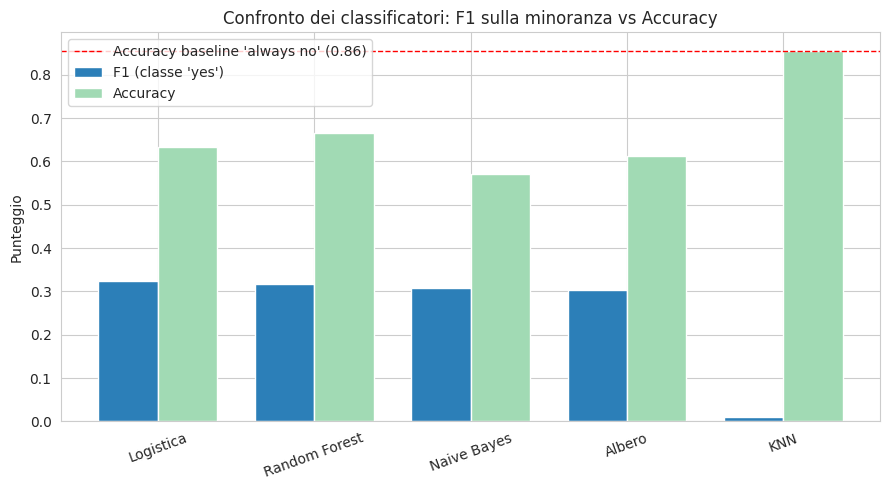

In [ ]:
baseline_acc = 1 - y_test.mean()   # accuracy del modello "predici sempre no"

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(tabella))
larghezza = 0.38

ax.bar(x - larghezza/2, tabella["test_f1"], larghezza,
       label="F1 (classe 'yes')", color="#2c7fb8")
ax.bar(x + larghezza/2, tabella["test_accuracy"], larghezza,
       label="Accuracy", color="#a1dab4")
ax.axhline(baseline_acc, color="red", linestyle="--", linewidth=1,
           label=f"Accuracy baseline 'always no' ({baseline_acc:.2f})")

ax.set_xticks(x)
ax.set_xticklabels(tabella["modello"], rotation=20)
ax.set_ylabel("Punteggio")
ax.set_title("Confronto dei classificatori: F1 sulla minoranza vs Accuracy")
ax.legend()
plt.tight_layout()
plt.show()

## 11. Selezione del classificatore finale e analisi critica

In [ ]:
# Indice del modello migliore per F1 sul test (idxmax, no loop)
idx_best = risultati["test_f1"].idxmax()
best_row = risultati.loc[idx_best]

print("=" * 55)
print(f"  MODELLO SELEZIONATO: {best_row['modello']}")
print("=" * 55)
print(f"  Iperparametri ottimali: {best_row['best_params']}")
print(f"  F1 (cross-validation):  {best_row['cv_f1']:.4f}")
print(f"  F1 (test set):          {best_row['test_f1']:.4f}")
print(f"  PR-AUC (test set):      {best_row['test_pr_auc']:.4f}")
print(f"  ROC-AUC (test set):     {best_row['test_roc_auc']:.4f}")

  MODELLO SELEZIONATO: Logistica
  Iperparametri ottimali: {'clf__C': 0.1}
  F1 (cross-validation):  0.3296
  F1 (test set):          0.3230
  PR-AUC (test set):      0.2813
  ROC-AUC (test set):     0.6663


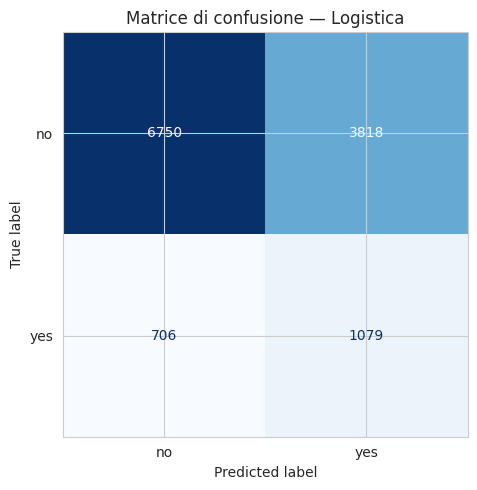


Classification report dettagliato:

              precision    recall  f1-score   support

          no       0.91      0.64      0.75     10568
         yes       0.22      0.60      0.32      1785

    accuracy                           0.63     12353
   macro avg       0.56      0.62      0.54     12353
weighted avg       0.81      0.63      0.69     12353



In [ ]:
# Matrice di confusione del modello finale (Lezione 8)
fig, ax = plt.subplots(figsize=(5.5, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, best_row["_pred"],
    display_labels=["no", "yes"],
    cmap="Blues", ax=ax, colorbar=False
)
ax.set_title(f"Matrice di confusione — {best_row['modello']}")
plt.tight_layout()
plt.show()

print("\nClassification report dettagliato:\n")
print(classification_report(y_test, best_row["_pred"],
                            target_names=["no", "yes"]))

### Curva Precision-Recall e ruolo della soglia decisionale

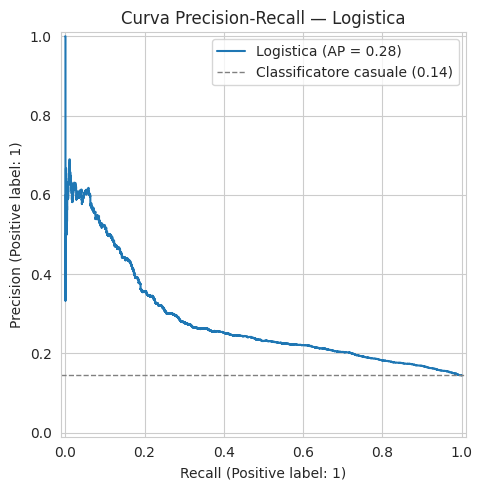

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))
PrecisionRecallDisplay.from_predictions(
    y_test, best_row["_proba"], name=best_row["modello"], ax=ax
)
# Linea di riferimento: precision di un classificatore casuale = prevalenza della classe
ax.axhline(y_test.mean(), color="grey", linestyle="--", linewidth=1,
           label=f"Classificatore casuale ({y_test.mean():.2f})")
ax.set_title(f"Curva Precision-Recall — {best_row['modello']}")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

## 12. Discussione critica dei risultati

## 13. Predisposizione per `real_settings.csv` (esame)

In [ ]:
# ============================================================
#  TEMPLATE PER L'ESAME — eseguire quando si riceve real_settings.csv
# ============================================================
# modello_finale = best_row["_estimator"]   # pipeline completa già addestrata
#
# real = pd.read_csv("real_settings.csv")    # adattare sep= se necessario
#
# # Allineamento alle stesse feature del training:
# real = real.drop(columns=["duration"], errors="ignore")  # coerenza anti-leakage
# X_real = real.drop(columns=["y"], errors="ignore")
#
# # Predizione (la pipeline applica preprocessing identico al training)
# pred_real = modello_finale.predict(X_real)
#
# # Se il file contiene la colonna 'y', valutiamo le prestazioni:
# if "y" in real.columns:
#     y_real = real["y"]
#     print(classification_report(y_real, pred_real, target_names=["no", "yes"]))
#     ConfusionMatrixDisplay.from_predictions(y_real, pred_real,
#                                             display_labels=["no", "yes"], cmap="Blues")
#     plt.show()
# else:
#     print("Predizioni generate:", pd.Series(pred_real).value_counts().to_dict())
print("Template pronto. Decommentare ed eseguire in sede d'esame.")

Template pronto. Decommentare ed eseguire in sede d'esame.


## 14. Conclusioni

In questo task abbiamo:

1. **rimosso la data leakage** escludendo `duration`, in coerenza con il test in
   condizioni reali (`real_settings.csv`);
2. costruito **pipeline complete** con `ColumnTransformer` (imputazione + scaling +
   one-hot), evitando ogni contaminazione tra training e test;
3. addestrato e **ottimizzato cinque classificatori** del corso con `GridSearchCV` e
   cross-validation stratificata;
4. **gestito lo sbilanciamento** con `class_weight="balanced"`, motivando la scelta
   rispetto a SMOTE;
5. valutato i modelli con la **metrica corretta** (F1 sulla minoranza, con PR-AUC di
   supporto), evitando la trappola dell'accuracy;
6. **selezionato il classificatore finale** e analizzato criticamente i risultati,
   collegandoli ai concetti delle Lezioni 3, 5–9 e 11.

Il modello scelto è incapsulato in una pipeline riutilizzabile, **pronta** per essere
applicata al file d'esame senza ulteriore preprocessing manuale.

### Concetti del corso utilizzati (riepilogo)

| Concetto | Lezione | Dove |
|---|---|---|
| Attributi numerici vs nominali | 3 | Sez. 4 |
| Naïve Bayes, KNN, alberi, modelli lineari | 5–7 | Sez. 8 |
| Holdout, stratificazione, metriche, confusion matrix | 8 | Sez. 5, 9, 11 |
| Cross-validation, tuning (GridSearchCV) | 9 | Sez. 10 |
| One-hot encoding, scaling, imputazione | 11 | Sez. 6 |
| Data leakage | trasversale | Sez. 3 |
| Sbilanciamento e `class_weight` | trasversale | Sez. 7 |
